# LSTM: Trajektorie lernen → danach Wurf klassifizieren (clean, noisy, trimmed)

Zielsetzung:
- Das LSTM lernt die Trajektorie \((x(t), y(t))\).
- Nach dem Training wird jede vorhergesagte Trajektorie klassifiziert:
  `0=zu kurz`, `1=Treffer`, `2=zu lang`.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Ground Truth vs. Vorhersage), Konfusionsmatrix & Metriken.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25*hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g/(2*(l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx=v0*np.cos(theta); vy=v0*np.sin(theta)
        x = vx*t; y = vy*t - 0.5*g*t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise: df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2*v0*np.sin(theta)/g; t = np.linspace(0, T, 50)
            x,y = self.wurftrajektorien(theta, v0, t)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x,y,t):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [3]:
def add_point_index_and_tnorm(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # point_index (1..50) pro Wurf – nach t sortiert
    d = d.sort_values(["wurf_id", "t"]).copy()
    d["point_index"] = d.groupby("wurf_id").cumcount() + 1

    # t_norm pro Wurf in [0,1]
    tmax = d.groupby("wurf_id")["t"].transform("max").replace(0, 1e-8)
    d["t_norm"] = (d["t"] / tmax).astype(np.float32)
    return d


def split_by_wurf_id(df: pd.DataFrame, test_size=0.2, seed=42):
    wids = df["wurf_id"].unique()
    tr, va = train_test_split(
        wids, test_size=test_size, random_state=seed, shuffle=True
    )
    return df[df["wurf_id"].isin(tr)].copy(), df[df["wurf_id"].isin(va)].copy()


class XYScaler:
    """Simple StandardScaler nur für x,y (fit nur auf Train!)."""

    def fit(self, xy: np.ndarray):
        self.mean_ = xy.mean(axis=0)
        self.std_ = xy.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, xy: np.ndarray):
        return (xy - self.mean_) / self.std_

    def inverse_transform(self, xy: np.ndarray):
        return xy * self.std_ + self.mean_

In [4]:
class FullSequenceDataset(Dataset):
    """
    Pro Sample = 1 Wurf
    X: (T,3) = [x_scaled, y_scaled, t_norm]
    Y: (T,2) = [x_scaled, y_scaled]  (Rekonstruktion / Vorhersage pro Schritt)
    C: int label
    """

    def __init__(self, df: pd.DataFrame, seq_len=50, scaler=None, fit_scaler=False):
        self.seq_len = seq_len
        self.df = add_point_index_and_tnorm(df)
        self.scaler = scaler if scaler is not None else XYScaler()

        self.throws = []
        for _, g in self.df.groupby("wurf_id"):
            g = g.sort_values("point_index")
            if len(g) >= seq_len:
                self.throws.append(g.iloc[:seq_len].copy())

        if fit_scaler:
            xy = np.concatenate(
                [g[["x", "y"]].values.astype(np.float32) for g in self.throws], axis=0
            )
            self.scaler.fit(xy)

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        g = self.throws[idx]
        xy = g[["x", "y"]].values.astype(np.float32)
        xy_s = self.scaler.transform(xy).astype(np.float32)
        t = g[["t_norm"]].values.astype(np.float32)

        X = np.concatenate([xy_s, t], axis=1)  # (T,3)
        Y = xy_s  # (T,2)
        C = int(g["label"].iloc[0])

        return (
            torch.from_numpy(X),
            torch.from_numpy(Y),
            torch.tensor(C, dtype=torch.long),
        )

In [5]:
class ExtrapolationDataset(Dataset):
    """
    Input:  first input_len points
    Target: next  pred_len points

    Returns:
      X_in:   (Tin,3)
      t_fut:  (Tpred,1)
      last_xy:(2,)   last observed xy (scaled)
      Y_fut:  (Tpred,2)
      C:      label
    """

    def __init__(
        self,
        df_full: pd.DataFrame,
        input_len=30,
        pred_len=20,
        scaler=None,
        fit_scaler=False,
    ):
        self.input_len = input_len
        self.pred_len = pred_len
        self.total_len = input_len + pred_len

        self.df = add_point_index_and_tnorm(df_full)
        self.scaler = scaler if scaler is not None else XYScaler()

        self.throws = []
        for _, g in self.df.groupby("wurf_id"):
            g = g.sort_values("point_index")
            if len(g) >= self.total_len:
                self.throws.append(g.iloc[: self.total_len].copy())

        if fit_scaler:
            xy = np.concatenate(
                [
                    g.iloc[:input_len][["x", "y"]].values.astype(np.float32)
                    for g in self.throws
                ],
                axis=0,
            )
            self.scaler.fit(xy)

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        g = self.throws[idx]
        xy = g[["x", "y"]].values.astype(np.float32)
        xy_s = self.scaler.transform(xy).astype(np.float32)
        t = g[["t_norm"]].values.astype(np.float32)

        X_in = np.concatenate(
            [xy_s[: self.input_len], t[: self.input_len]], axis=1
        )  # (Tin,3)
        Y_fut = xy_s[self.input_len : self.total_len]  # (Tpred,2)
        t_fut = t[self.input_len : self.total_len]  # (Tpred,1)
        last_xy = xy_s[self.input_len - 1]  # (2,)
        C = int(g["label"].iloc[0])

        return (
            torch.from_numpy(X_in),
            torch.from_numpy(t_fut),
            torch.from_numpy(last_xy),
            torch.from_numpy(Y_fut),
            torch.tensor(C, dtype=torch.long),
        )

In [6]:
class SeqRegClsModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.reg_head = nn.Linear(hidden_dim, 2)      # xy pro Schritt
        self.cls_head = nn.Linear(hidden_dim, n_classes)  # Logits pro Wurf

    def forward(self, x):  # x: (B,T,3)
        out, _ = self.enc(x)                          # out: (B,T,H)
        xy_hat = self.reg_head(out)                   # (B,T,2)
        logits = self.cls_head(out[:, -1, :])         # (B,C)
        return xy_hat, logits


class ExtrapSeq2SeqModel(nn.Module):
    """
    Decoder bekommt pro Schritt [prev_x, prev_y, t_future] und gibt next (x,y) aus.
    Training kann Teacher Forcing verwenden, Eval läuft autoregressiv.
    """

    def __init__(
        self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1
    ):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
        )
        self.dec_cell = nn.LSTMCell(input_size=3, hidden_size=hidden_dim)
        self.out_head = nn.Linear(hidden_dim, 2)
        self.cls_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, x_in, t_future, last_obs_xy, y_future=None, teacher_forcing=True):
        """
        x_in:       (B,Tin,3)
        t_future:   (B,Tpred,1)
        last_obs_xy:(B,2)
        y_future:   (B,Tpred,2) optional (scaled)
        """
        enc_out, (hN, cN) = self.enc(x_in)
        logits = self.cls_head(enc_out[:, -1, :])

        h = hN[-1]  # (B,H)
        c = cN[-1]

        preds = []
        prev_xy = last_obs_xy
        Tpred = t_future.shape[1]

        for k in range(Tpred):
            dec_in = torch.cat([prev_xy, t_future[:, k, :]], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            xy_k = self.out_head(h)
            preds.append(xy_k.unsqueeze(1))

            if teacher_forcing and (y_future is not None):
                prev_xy = y_future[:, k, :]
            else:
                prev_xy = xy_k

        y_hat = torch.cat(preds, dim=1)  # (B,Tpred,2)
        return y_hat, logits

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix


def train_full_seq(
    model, train_loader, val_loader, device="cpu", epochs=20, lr=1e-3, cls_weight=0.2
):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_ce": [],
        "val_ce": [],
        "train_acc": [],
        "val_acc": [],
    }

    for ep in range(1, epochs + 1):
        # ---- train ----
        model.train()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0

        for X, Y, C in train_loader:
            X, Y, C = X.to(device), Y.to(device), C.to(device)
            opt.zero_grad()

            Yhat, logits = model(X)
            loss_mse = mse(Yhat, Y)
            loss_ce = ce(logits, C)
            loss = loss_mse + cls_weight * loss_ce

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            sum_loss += loss.item() * X.size(0)
            sum_mse += loss_mse.item() * X.size(0)
            sum_ce += loss_ce.item() * X.size(0)

            pred = logits.argmax(1)
            correct += (pred == C).sum().item()
            total += X.size(0)

        tr_loss = sum_loss / len(train_loader.dataset)
        tr_mse = sum_mse / len(train_loader.dataset)
        tr_ce = sum_ce / len(train_loader.dataset)
        tr_acc = correct / max(total, 1)

        # ---- val ----
        model.eval()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0
        ytrue, ypred = [], []

        with torch.no_grad():
            for X, Y, C in val_loader:
                X, Y, C = X.to(device), Y.to(device), C.to(device)

                Yhat, logits = model(X)
                loss_mse = mse(Yhat, Y)
                loss_ce = ce(logits, C)
                loss = loss_mse + cls_weight * loss_ce

                sum_loss += loss.item() * X.size(0)
                sum_mse += loss_mse.item() * X.size(0)
                sum_ce += loss_ce.item() * X.size(0)

                pred = logits.argmax(1)
                correct += (pred == C).sum().item()
                total += X.size(0)

                ytrue.extend(C.cpu().numpy().tolist())
                ypred.extend(pred.cpu().numpy().tolist())

        va_loss = sum_loss / len(val_loader.dataset)
        va_mse = sum_mse / len(val_loader.dataset)
        va_ce = sum_ce / len(val_loader.dataset)
        va_acc = correct / max(total, 1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(va_mse)
        history["train_ce"].append(tr_ce)
        history["val_ce"].append(va_ce)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"[Full] ep={ep:02d} train={tr_loss:.4f} val={va_loss:.4f} acc={va_acc:.3f}"
            )
            print(classification_report(ytrue, ypred, digits=3))

    return model, history


def train_extrap(
    model, train_loader, val_loader, device="cpu", epochs=30, lr=1e-3, cls_weight=0.2
):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_ce": [],
        "val_ce": [],
        "train_acc": [],
        "val_acc": [],
    }

    for ep in range(1, epochs + 1):
        # ---- train (teacher forcing) ----
        model.train()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0

        for X_in, t_fut, last_xy, Y_fut, C in train_loader:
            X_in, t_fut, last_xy, Y_fut, C = (
                X_in.to(device),
                t_fut.to(device),
                last_xy.to(device),
                Y_fut.to(device),
                C.to(device),
            )
            opt.zero_grad()

            Yhat, logits = model(
                X_in, t_fut, last_xy, y_future=Y_fut, teacher_forcing=True
            )

            loss_mse = mse(Yhat, Y_fut)
            loss_ce = ce(logits, C)
            loss = loss_mse + cls_weight * loss_ce

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            sum_loss += loss.item() * X_in.size(0)
            sum_mse += loss_mse.item() * X_in.size(0)
            sum_ce += loss_ce.item() * X_in.size(0)

            pred = logits.argmax(1)
            correct += (pred == C).sum().item()
            total += X_in.size(0)

        tr_loss = sum_loss / len(train_loader.dataset)
        tr_mse = sum_mse / len(train_loader.dataset)
        tr_ce = sum_ce / len(train_loader.dataset)
        tr_acc = correct / max(total, 1)

        # ---- val (autoregressiv, kein teacher forcing) ----
        model.eval()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0
        ytrue, ypred = [], []

        with torch.no_grad():
            for X_in, t_fut, last_xy, Y_fut, C in val_loader:
                X_in, t_fut, last_xy, Y_fut, C = (
                    X_in.to(device),
                    t_fut.to(device),
                    last_xy.to(device),
                    Y_fut.to(device),
                    C.to(device),
                )

                Yhat, logits = model(
                    X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
                )

                loss_mse = mse(Yhat, Y_fut)
                loss_ce = ce(logits, C)
                loss = loss_mse + cls_weight * loss_ce

                sum_loss += loss.item() * X_in.size(0)
                sum_mse += loss_mse.item() * X_in.size(0)
                sum_ce += loss_ce.item() * X_in.size(0)

                pred = logits.argmax(1)
                correct += (pred == C).sum().item()
                total += X_in.size(0)

                ytrue.extend(C.cpu().numpy().tolist())
                ypred.extend(pred.cpu().numpy().tolist())

        va_loss = sum_loss / len(val_loader.dataset)
        va_mse = sum_mse / len(val_loader.dataset)
        va_ce = sum_ce / len(val_loader.dataset)
        va_acc = correct / max(total, 1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(va_mse)
        history["train_ce"].append(tr_ce)
        history["val_ce"].append(va_ce)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"[Extrap] ep={ep:02d} train={tr_loss:.4f} val={va_loss:.4f} acc={va_acc:.3f}"
            )
            print(classification_report(ytrue, ypred, digits=3))

    return model, history

In [16]:
def plot_training_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train total")
    plt.plot(epochs, history["val_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}Training Loss (total)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_mse"], label="train MSE")
    plt.plot(epochs, history["val_mse"], label="val MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"{title_prefix}Regression Loss (MSE)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train acc")
    plt.plot(epochs, history["val_acc"], label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}Classification Accuracy")
    plt.legend()
    plt.show()


def plot_pred_vs_gt_trajectory(
    model, val_loader, scaler, device="cpu", sample_idx_in_batch=0
):
    model.eval()
    batch = next(iter(val_loader))
    X, Y, C = batch
    X = X.to(device)

    with torch.no_grad():
        Yhat_s, logits = model(X)  # scaled prediction

    # pick one sample from batch
    Yhat_s = Yhat_s[sample_idx_in_batch].cpu().numpy()  # (T,2) scaled
    Y_s = Y[sample_idx_in_batch].cpu().numpy()  # (T,2) scaled

    # inverse scale to original units
    Yhat = scaler.inverse_transform(Yhat_s)
    Ygt = scaler.inverse_transform(Y_s)

    plt.figure()
    plt.plot(Ygt[:, 0], Ygt[:, 1], label="Ground Truth")
    plt.plot(Yhat[:, 0], Yhat[:, 1], label="Prediction")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trajectory: Prediction vs Ground Truth (val sample)")
    plt.legend()
    plt.show()


def plot_extrapolation_trajectory(
    model, val_loader, scaler, device="cpu", sample_idx_in_batch=0
):
    """
    Plottet:
      - observed GT (1..30)
      - future GT   (31..50)
      - future pred (31..50)
    im Originalmaßstab (inverse scaling).
    """
    model.eval()
    X_in, t_fut, last_xy, Y_fut, C = next(iter(val_loader))

    X_in = X_in.to(device)
    t_fut = t_fut.to(device)
    last_xy = last_xy.to(device)

    with torch.no_grad():
        Yhat_fut_s, logits = model(
            X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
        )

    # pick one sample
    x_in_s = X_in[sample_idx_in_batch].cpu().numpy()  # (30,3) -> first 2 are scaled xy
    y_gt_s = Y_fut[sample_idx_in_batch].cpu().numpy()  # (20,2) scaled
    y_hat_s = Yhat_fut_s[sample_idx_in_batch].cpu().numpy()  # (20,2) scaled

    xy_obs_s = x_in_s[:, :2]  # scaled
    xy_obs = scaler.inverse_transform(xy_obs_s)
    y_gt = scaler.inverse_transform(y_gt_s)
    y_hat = scaler.inverse_transform(y_hat_s)

    plt.figure()
    plt.plot(xy_obs[:, 0], xy_obs[:, 1], label="Observed GT (1..30)")
    plt.plot(y_gt[:, 0], y_gt[:, 1], label="Future GT (31..50)")
    plt.plot(y_hat[:, 0], y_hat[:, 1], label="Future Pred (31..50)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Extrapolation Trajectory: 30 observed -> 20 predicted")
    plt.legend()
    plt.show()


def plot_confusion_matrix(model, val_loader, device="cpu", class_names=None):
    model.eval()
    ytrue, ypred = [], []

    with torch.no_grad():
        for X, Y, C in val_loader:
            X = X.to(device)
            C = C.to(device)
            _, logits = model(X)
            pred = logits.argmax(1)
            ytrue.extend(C.cpu().numpy().tolist())
            ypred.extend(pred.cpu().numpy().tolist())

    cm = confusion_matrix(ytrue, ypred)
    n = cm.shape[0]

    if class_names is None:
        class_names = [f"class {i}" for i in range(n)]

    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(n)
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # Zahlen in die Zellen schreiben
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_extrap(model, val_loader, device="cpu", class_names=None):
    model.eval()
    ytrue, ypred = [], []

    with torch.no_grad():
        for X_in, t_fut, last_xy, Y_fut, C in val_loader:
            X_in, t_fut, last_xy = X_in.to(device), t_fut.to(device), last_xy.to(device)
            _, logits = model(
                X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
            )
            pred = logits.argmax(1)

            ytrue.extend(C.numpy().tolist())
            ypred.extend(pred.cpu().numpy().tolist())

    cm = confusion_matrix(ytrue, ypred)
    n = cm.shape[0]
    if class_names is None:
        class_names = [f"class {i}" for i in range(n)]

    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Extrapolation)")
    plt.colorbar()
    ticks = np.arange(n)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

## Clean‑Training → Wurfklassifikation

[Full] ep=01 train=1.0507 val=0.6644 acc=0.256
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        35
           1      0.256     1.000     0.407        23
           2      0.000     0.000     0.000        32

    accuracy                          0.256        90
   macro avg      0.085     0.333     0.136        90
weighted avg      0.065     0.256     0.104        90



c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

[Full] ep=05 train=0.2291 val=0.1903 acc=0.878
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     0.522     0.686        23
           2      0.744     1.000     0.853        32

    accuracy                          0.878        90
   macro avg      0.915     0.841     0.846        90
weighted avg      0.909     0.878     0.868        90

[Full] ep=10 train=0.0238 val=0.0192 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     1.000     1.000        23
           2      1.000     1.000     1.000        32

    accuracy                          1.000        90
   macro avg      1.000     1.000     1.000        90
weighted avg      1.000     1.000     1.000        90

[Full] ep=15 train=0.0053 val=0.0035 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.00

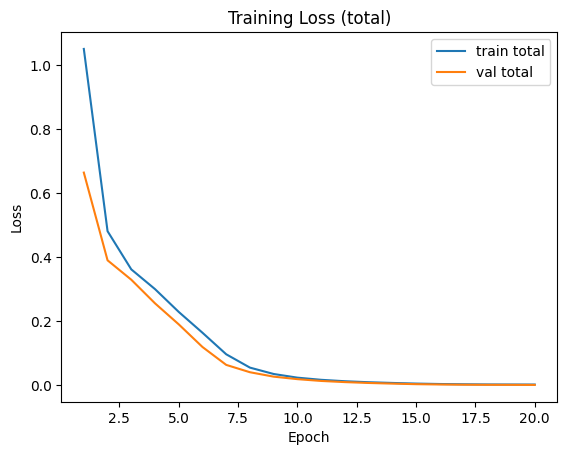

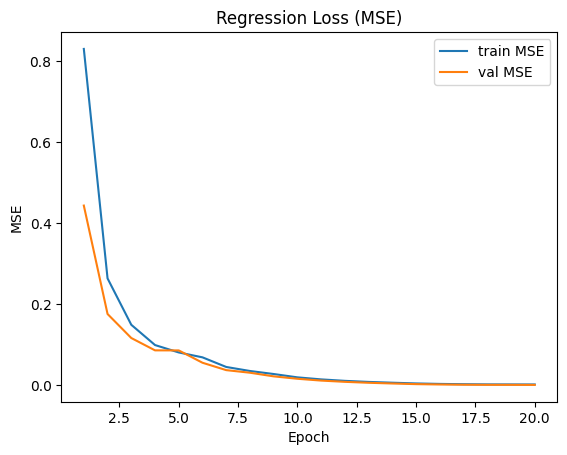

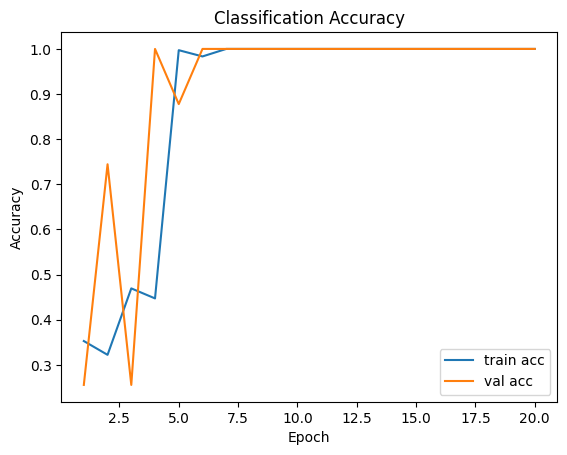

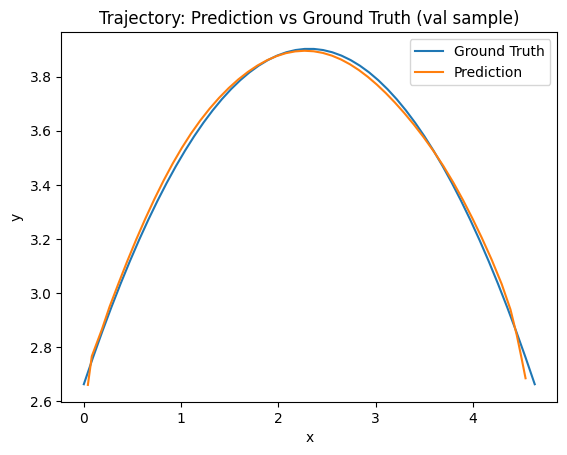

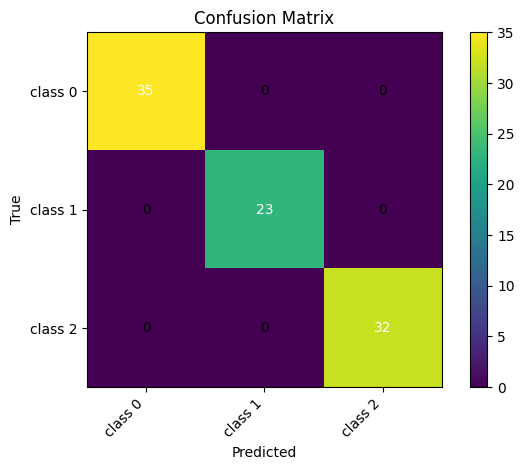

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dg = DataGen()
df_clean = dg.generate_dataset(with_noise=False)
df_clean_full = df_clean.copy()

tr_df, va_df = split_by_wurf_id(df_clean_full, test_size=0.2, seed=42)
scaler = XYScaler()
train_ds = FullSequenceDataset(tr_df, seq_len=50, scaler=scaler, fit_scaler=True)
val_ds   = FullSequenceDataset(va_df, seq_len=50, scaler=scaler, fit_scaler=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

model_full_clean = SeqRegClsModel(hidden_dim=128, num_layers=2)
model_full_clean, hist = train_full_seq(
    model_full_clean, train_loader, val_loader, device=device, epochs=20
)

plot_training_history(hist)
plot_pred_vs_gt_trajectory(model_full_clean, val_loader, scaler=train_ds.scaler, device=device, sample_idx_in_batch=0)

# Wenn du Label-Namen hast, z.B. ["low","mid","high"] eintragen:
plot_confusion_matrix(model_full_clean, val_loader, device=device, class_names=None)


## Noisy‑Training → Wurfklassifikation

[Full] ep=01 train=1.0683 val=0.6892 acc=0.356
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        35
           1      0.000     0.000     0.000        23
           2      0.525     1.000     0.688        32

    accuracy                          0.356        90
   macro avg      0.175     0.333     0.229        90
weighted avg      0.187     0.356     0.245        90



c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

[Full] ep=05 train=0.2171 val=0.1717 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     1.000     1.000        23
           2      1.000     1.000     1.000        32

    accuracy                          1.000        90
   macro avg      1.000     1.000     1.000        90
weighted avg      1.000     1.000     1.000        90

[Full] ep=10 train=0.0401 val=0.0353 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     1.000     1.000        23
           2      1.000     1.000     1.000        32

    accuracy                          1.000        90
   macro avg      1.000     1.000     1.000        90
weighted avg      1.000     1.000     1.000        90

[Full] ep=15 train=0.0202 val=0.0176 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.00

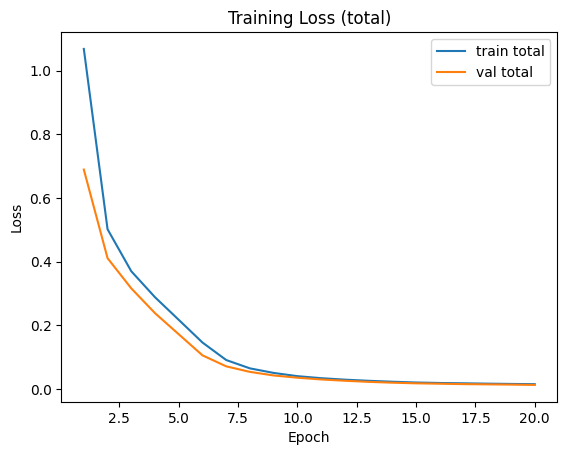

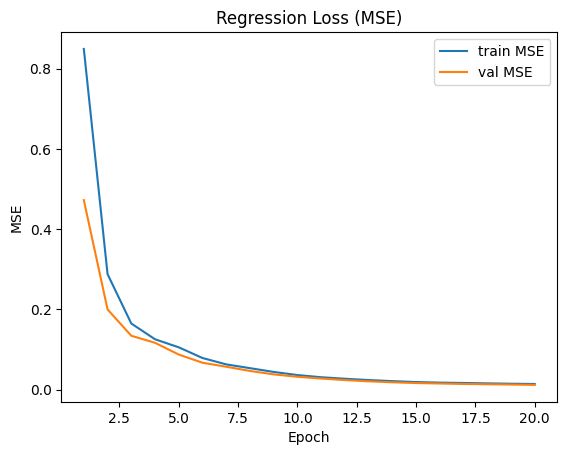

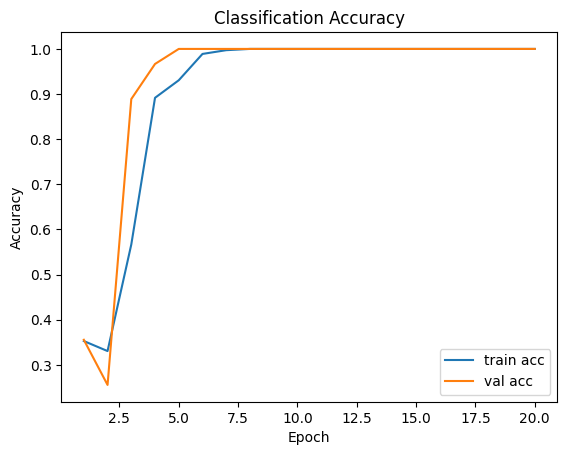

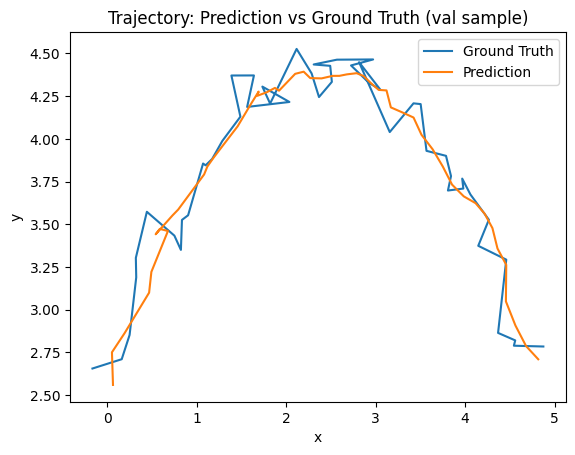

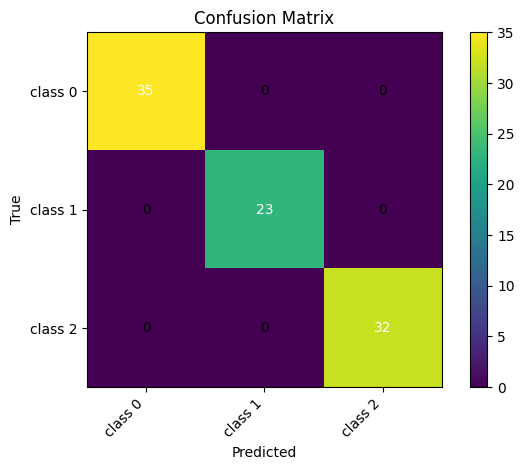

In [12]:
df_noisy = dg.generate_dataset(with_noise=True)
df_noisy_full = df_noisy.copy()

tr_df_n, va_df_n = split_by_wurf_id(df_noisy_full, test_size=0.2, seed=42)
scaler = XYScaler()
train_ds_n = FullSequenceDataset(tr_df_n, seq_len=50, scaler=scaler, fit_scaler=True)
val_ds_n = FullSequenceDataset(va_df_n, seq_len=50, scaler=scaler, fit_scaler=False)

train_loader_n = DataLoader(train_ds_n, batch_size=32, shuffle=True)
val_loader_n = DataLoader(val_ds_n, batch_size=64, shuffle=False)

model_full_noisy = SeqRegClsModel(hidden_dim=128, num_layers=2)
model_full_noisy, hist_n = train_full_seq(
    model_full_noisy, train_loader_n, val_loader_n, device=device, epochs=20
)

plot_training_history(hist_n)
plot_pred_vs_gt_trajectory(
    model_full_noisy,
    val_loader_n,
    scaler=train_ds_n.scaler,
    device=device,
    sample_idx_in_batch=0,
)

# Wenn du Label-Namen hast, z.B. ["low","mid","high"] eintragen:
plot_confusion_matrix(model_full_noisy, val_loader_n, device=device, class_names=None)

## Trimmed‑Training → Wurfklassifikation

[Extrap] ep=01 train=4.0815 val=3.1663 acc=0.356
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        35
           1      0.000     0.000     0.000        23
           2      0.582     1.000     0.736        32

    accuracy                          0.356        90
   macro avg      0.194     0.333     0.245        90
weighted avg      0.207     0.356     0.262        90



c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

[Extrap] ep=05 train=0.0584 val=0.0394 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     1.000     1.000        23
           2      1.000     1.000     1.000        32

    accuracy                          1.000        90
   macro avg      1.000     1.000     1.000        90
weighted avg      1.000     1.000     1.000        90

[Extrap] ep=10 train=0.0056 val=0.0086 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      1.000     1.000     1.000        23
           2      1.000     1.000     1.000        32

    accuracy                          1.000        90
   macro avg      1.000     1.000     1.000        90
weighted avg      1.000     1.000     1.000        90

[Extrap] ep=15 train=0.0035 val=0.0075 acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000   

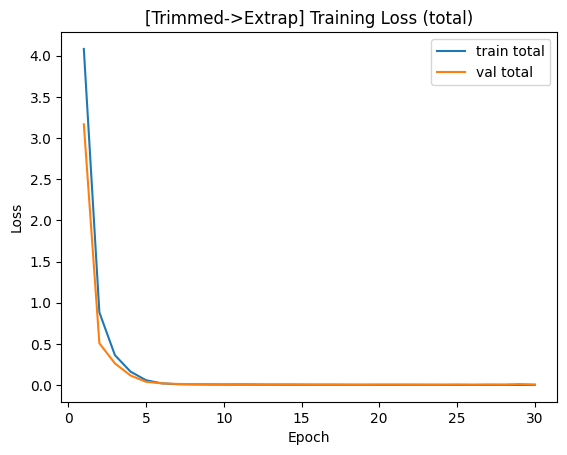

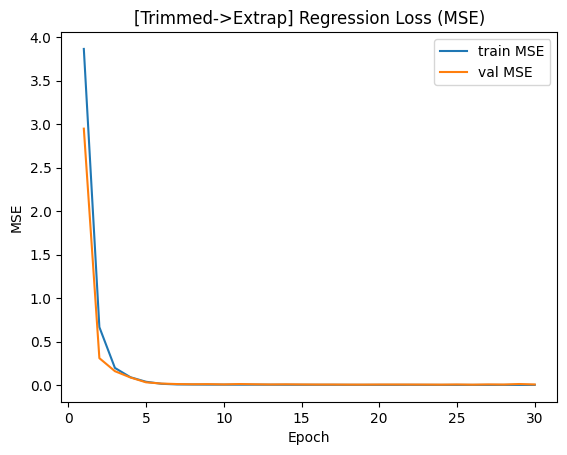

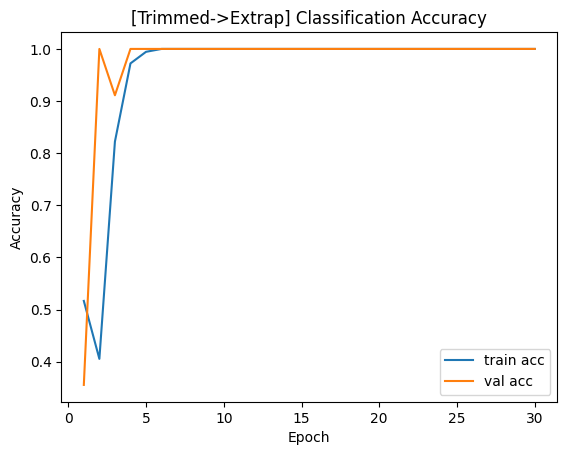

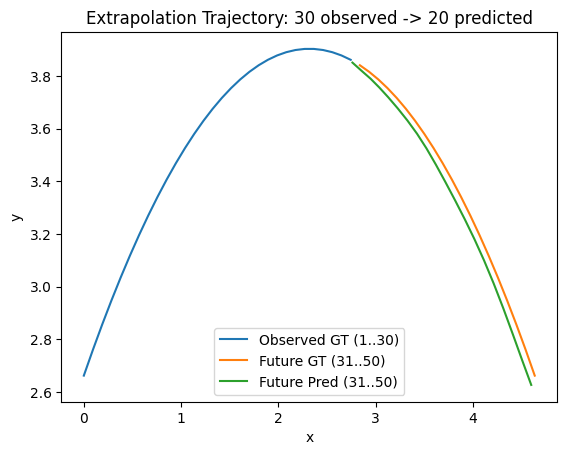

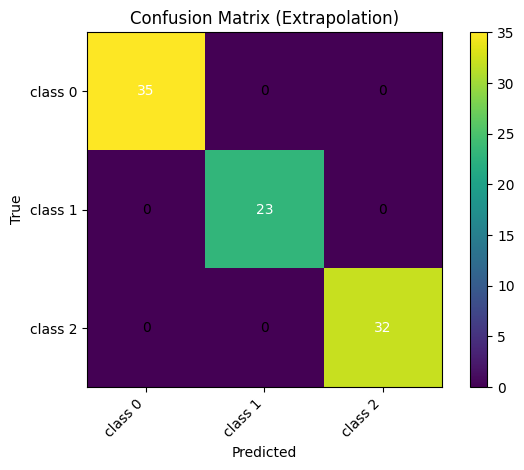

In [19]:
df_clean_full_for_extrap = df_clean_full.copy()

tr_df, va_df = split_by_wurf_id(df_clean_full_for_extrap, test_size=0.2, seed=42)
scaler = XYScaler()
train_ds = ExtrapolationDataset(
    tr_df, input_len=30, pred_len=20, scaler=scaler, fit_scaler=True
)
val_ds = ExtrapolationDataset(
    va_df, input_len=30, pred_len=20, scaler=scaler, fit_scaler=False
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

model_extrap_clean = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2)
model_extrap_clean, hist_ex = train_extrap(
    model_extrap_clean, train_loader, val_loader, device=device, epochs=30
)

plot_training_history(hist_ex, title_prefix="[Trimmed->Extrap] ")
plot_extrapolation_trajectory(
    model_extrap_clean,
    val_loader,
    scaler=train_ds.scaler,
    device=device,
    sample_idx_in_batch=0,
)
plot_confusion_matrix_extrap(
    model_extrap_clean, val_loader, device=device, class_names=None
)